#**Importy**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
base_path = Path('/content/drive/MyDrive/CSV')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

#**Wnioski z poprzedniego zadania**

In [4]:
titanic_df = pd.read_csv(base_path / 'titanic_prepared.csv', index_col='PassengerId')

In [5]:
titanic_df.head()

,Survived,Pclass,IsFemale,Age,SibSp,Parch,Fare,IsAlone,IsChild,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,0,0,1,0,0
3,1,3,1,26.0,0,0,7.9250,1,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,0,0,0,0,1
5,0,3,0,35.0,0,0,8.0500,1,0,0,0,1


Wnioski:

*   Dane będą wymagać standaryzacji
*   Kolumny Age i Fare posiadają outliery i trzeba je uwzględnić przy tworzeniu modelu
*   Jest duża różnica między płciami pod kątem przeżywalności, więc będzie to cecha, która będzie miała duże znaczenie
*   Sam rozkład wieku był "w miarę" symetryczny, jednak fakt bycia dzieckiem odgrywał duże znaczenie.
*  Kolumny, które nie dawały już wartości zostały usunięte.
*  Rozkład Survived nie jest znieszkształcony i wynosi mniej więcej 40/60, więc metryka, która będę się przedewszystkim kierował to Accuracy.
*  Dodatkowo będę zwracał uwagę na $F_1$, by mieć pewność, że model nie faworyzuje klasy dominującej.



#**Podział zbioru i Dummy Classifier**


In [6]:
X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)
print("Baseline Accuracy: %.4f" % accuracy_score(y_test, y_pred_dummy))

Baseline Accuracy: 0.6145


#**KNN**

In [7]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11, 13, 15], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [8]:
print("\nNajlepsze parametry KNN:", grid_search_knn.best_params_)
y_pred_knn = grid_search_knn.predict(X_test_scaled)
print("KNN Accuracy: %.4f" % accuracy_score(y_test, y_pred_knn))
print("\nRaport klasyfikacji KNN:\n", classification_report(y_test, y_pred_knn))


Najlepsze parametry KNN: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
KNN Accuracy: 0.7709

Raport klasyfikacji KNN:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77      0.77      0.77       179



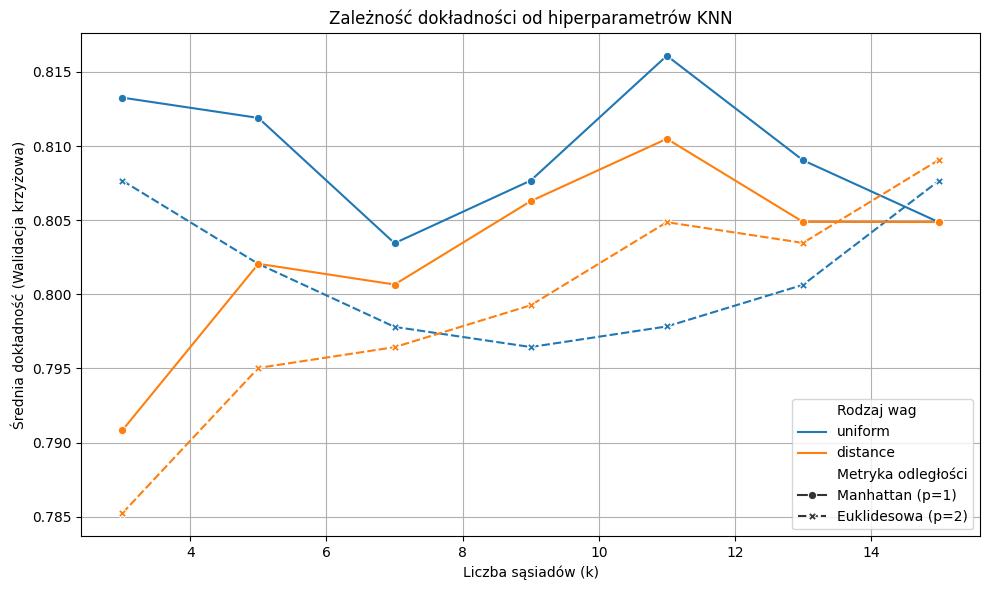

In [9]:
results_knn = pd.DataFrame(grid_search_knn.cv_results_)

results_knn = results_knn.rename(columns={
    'param_n_neighbors': 'Liczba sąsiadów (k)',
    'param_weights': 'Rodzaj wag',
    'param_p': 'Metryka odległości'
})

results_knn['Metryka odległości'] = results_knn['Metryka odległości'].map(
    {1: 'Manhattan (p=1)', 2: 'Euklidesowa (p=2)'}
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results_knn,
    x='Liczba sąsiadów (k)',
    y='mean_test_score',
    hue='Rodzaj wag',
    style='Metryka odległości',
    markers=True,
    dashes=True
)

plt.title("Zależność dokładności od hiperparametrów KNN")
plt.ylabel("Średnia dokładność (Walidacja krzyżowa)")
plt.grid(True)
plt.tight_layout()
plt.show()

Analizowane hiperparametry:


1.   Ilość sąsiadów


*   Przy mniejszej ilości sąsiadów model bardziej dostosowuje się do lokalnego szumu
*   Przy zbyt dużej ilości sąsiadów model zbytnio wygładzał wartości przez odległe punkty


2.   Rodzaje wag


*   Przy dużym k uniform powoduje, że przegłosować mogą odległe punkty klasy większościowej
*   Distance rozwiązuje ten problem, jednak przy małym k najbliższy punkt może zbyt dominować

3. Rodzaje metryk odległości.


*   Ponieważ wartości w tabeli zostały przeskalowane, obie metryki miały zbliżone rezultaty







**XGBoost**

In [10]:
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100]
}

grid_search_xgb = GridSearchCV(xgb_clf, param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7, 9], 'n_estimators': [100]},
             scoring='accuracy')

In [11]:
print("Najlepsze parametry XGBoost:", grid_search_xgb.best_params_)
y_pred_xgb = grid_search_xgb.predict(X_test)
print("XGBoost Accuracy: %.4f" % accuracy_score(y_test, y_pred_xgb))
print("\nRaport klasyfikacji XGBoost:\n", classification_report(y_test, y_pred_xgb))


Najlepsze parametry XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost Accuracy: 0.7989

Raport klasyfikacji XGBoost:
               precision    recall  f1-score   support

           0       0.78      0.94      0.85       110
           1       0.85      0.58      0.69        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179



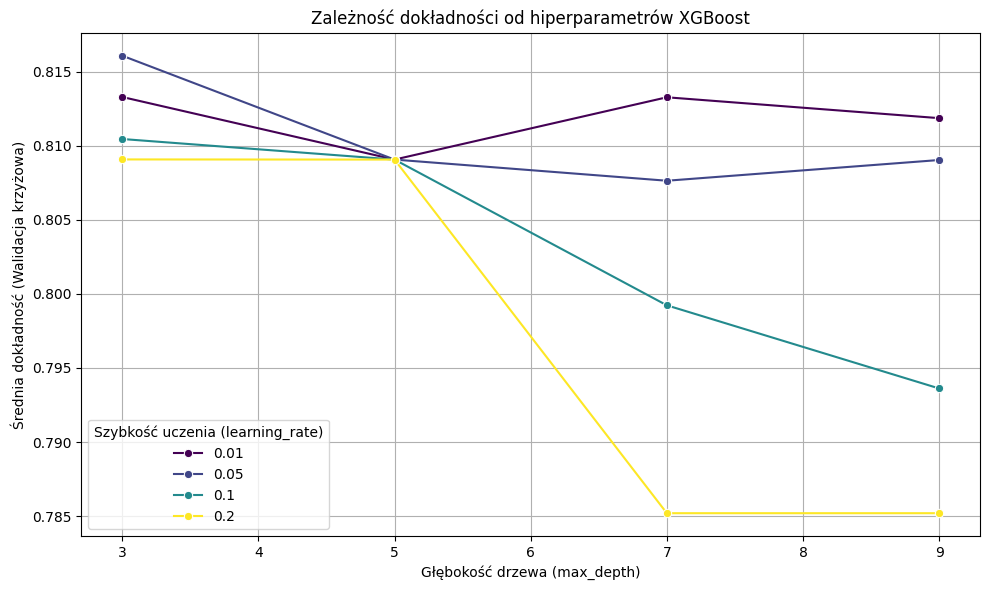

In [12]:
results_xgb = pd.DataFrame(grid_search_xgb.cv_results_)

results_xgb = results_xgb.rename(columns={
    'param_max_depth': 'Głębokość drzewa (max_depth)',
    'param_learning_rate': 'Szybkość uczenia (learning_rate)'
})

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results_xgb,
    x='Głębokość drzewa (max_depth)',
    y='mean_test_score',
    hue='Szybkość uczenia (learning_rate)',
    palette='viridis',
    marker='o'
)
plt.title("Zależność dokładności od hiperparametrów XGBoost")
plt.ylabel("Średnia dokładność (Walidacja krzyżowa)")
plt.grid(True)
plt.tight_layout()
plt.show()

Analizowane hiperparametry:


1.   Głębokość drzewa

*    Model przy zbyt dużej głębokości uczy się specyfiki zbioru treningowego i dochodzi do przeuczenia
*  Przy mniejszej głębokości model tworzy prostsze reguły, więc jest bardziej odporny na zbiór treningowy

2.   Szybkość uczenia


*   Przy mniejszych wartościach model ostrożniej optymalizuje błąd i uodparnia go na osiadanie w minimach lokalnych
*   Przy zbyt dużych wartościach model przeskakuje optymalne rozwiązania








#**Wnioski**

XGBoost osiągnał wynik prawie 80%, natomiast KNN ok. 77%, co jest wynikami wyższymi niż DummyClassifier 61%

XGBoost wykazuje wysoką czułość w wykrywaniu ofiar, natomiast rzadziej wskazuje na tych, co przeżyli

KNN jest bardziej zbalansowany na poziomie klas. Lepiej typuje osoby, które przeżyły katastrofę, niż XGBoost, pomimo tego ogólnie ma niższe accuracy